# Unsupervised Learning: Regional Stunting Clustering Analysis

In [1]:
# Import core libraries for data manipulation, clustering, missing value imputation, and geographical mapping
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
import folium
import json
import warnings
warnings.filterwarnings('ignore')

# Set matplotlib graphic resolution globally to 500 DPI for publication standard
mpl.rcParams['figure.dpi'] = 500
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman'] + mpl.rcParams['font.serif']
sns.set_theme(style='whitegrid')
print("All libraries successfully imported with 500 DPI visualization settings!")

All libraries successfully imported with 500 DPI visualization settings!


## 1. Load Regional Nutritional Status Dataset
We load the regional/district nutritional status dataset from Excel and map the columns.

In [2]:
excel_path = 'dataset/Data-Status-Gizi-2018-2020-Kabupaten-Kota.xlsx'

# Read the header line specifically at index 4 (5th row in Excel)
df_raw = pd.read_excel(excel_path, sheet_name='Data', skiprows=4)

# Clean and name the main columns
rename_dict = {
    df_raw.columns[1]: 'Province',
    df_raw.columns[2]: 'Regency_City',
    df_raw.columns[4]: 'Total_Births',
    df_raw.columns[35]: 'Stunting_2019',
    df_raw.columns[37]: 'Maternal_Wasting',
    df_raw.columns[38]: 'Complete_Basic_Immunization',
    df_raw.columns[39]: 'Low_Birth_Weight'
}
df_clean = df_raw.rename(columns=rename_dict)
keep_cols = list(rename_dict.values())
df_clean = df_clean[keep_cols]

# Remove empty rows or rows without province names
df_clean = df_clean.dropna(subset=['Province', 'Regency_City'])
df_clean['Province'] = df_clean['Province'].astype(str).str.strip()

print(f"Raw dataset loaded successfully. Total rows: {df_clean.shape[0]}, Total columns: {df_clean.shape[1]}")

Raw dataset loaded successfully. Total rows: 514, Total columns: 7


## 2. Initial Data Inspection
Displays the first 5 rows of the cleaned district-level dataset.

In [3]:
df_clean.head()

,Province,Regency_City,Total_Births,Stunting_2019,Maternal_Wasting,Complete_Basic_Immunization,Low_Birth_Weight
0,Aceh,Simeulue,2876.256,28.8,0.136555,0.542858,0.044060
1,Aceh,Aceh Singkil,5507.150,37.4,0.108781,0.567045,0.058867
2,Aceh,Aceh Selatan,5964.009,30.9,0.215570,0.251362,0.136317
3,Aceh,Aceh Tenggara,9511.544,43.4,0.045437,0.115863,0.024592
4,Aceh,Aceh Timur,11246.628,24.6,0.184270,0.124985,0.133027


### 2.1 Data Types and Completeness Information
Checks the data type of each column and inspects missing values.

In [4]:
df_clean.info()
print("\nJumlah baris duplikat:", df_clean.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 514 entries, 0 to 513
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Province                     514 non-null    str    
 1   Regency_City                 514 non-null    str    
 2   Total_Births                 514 non-null    float64
 3   Stunting_2019                514 non-null    float64
 4   Maternal_Wasting             453 non-null    float64
 5   Complete_Basic_Immunization  503 non-null    float64
 6   Low_Birth_Weight             474 non-null    float64
dtypes: float64(5), str(2)
memory usage: 28.2 KB

Jumlah baris duplikat: 0


## 3. Birth-Weighted Aggregation at Province Level
To obtain statistically sound prevalence at the provincial level, we perform birth-weighted averaging using the number of births in each district as weights.

In [5]:
def calculate_weighted_avg(group, value_col, weight_col):
    values = group[value_col].astype(float)
    weights = group[weight_col].astype(float)
    valid = ~(values.isna() | weights.isna())
    if not valid.any() or weights[valid].sum() == 0:
        return np.nan
    return np.average(values[valid], weights=weights[valid])

prov_data = []
grouped = df_clean.groupby('Province')

for prov_name, group in grouped:
    total_births = group['Total_Births'].sum(min_count=1)
    stunting_19 = calculate_weighted_avg(group, 'Stunting_2019', 'Total_Births')
    kek = calculate_weighted_avg(group, 'Maternal_Wasting', 'Total_Births')
    idl = calculate_weighted_avg(group, 'Complete_Basic_Immunization', 'Total_Births')
    bblr = calculate_weighted_avg(group, 'Low_Birth_Weight', 'Total_Births')

    prov_data.append({
        'Province': prov_name,
        'Total_Births': total_births,
        'Stunting_2019': stunting_19,
        'Maternal_Wasting': kek,
        'Complete_Basic_Immunization': idl,
        'Low_Birth_Weight': bblr
    })

df_prov = pd.DataFrame(prov_data)
df_prov.head()

,Province,Total_Births,Stunting_2019,Maternal_Wasting,Complete_Basic_Immunization,Low_Birth_Weight
0,Aceh,171718.723,35.392169,0.121565,0.210334,0.067376
1,Bali,45182.469,15.972776,0.129219,0.917864,0.060494
2,Bangka Belitung,24715.078,20.305718,0.164611,0.741730,0.056877
3,Banten,254076.461,26.583807,0.183923,0.419527,0.052752
4,Bengkulu,44151.077,27.704721,0.144251,0.623825,0.053565


## 4. Smart Missing Value Imputation Using KNN Imputer
Imputes missing values using the KNN Imputer (K=5) based on the profile similarity between provinces.

In [6]:
# Check the number of missing values at the provincial level before imputation
print("Missing values before KNN Imputation:")
print(df_prov.isnull().sum())

# Menerapkan KNN Imputer
imputer = KNNImputer(n_neighbors=5)
numeric_cols = ['Total_Births', 'Stunting_2019', 'Maternal_Wasting', 'Complete_Basic_Immunization', 'Low_Birth_Weight']
df_prov[numeric_cols] = imputer.fit_transform(df_prov[numeric_cols])

print("\nMissing values after KNN Imputation:")
print(df_prov.isnull().sum())

Missing values before KNN Imputation:
Province                       0
Total_Births                   0
Stunting_2019                  0
Maternal_Wasting               0
Complete_Basic_Immunization    0
Low_Birth_Weight               0
dtype: int64

Missing values after KNN Imputation:
Province                       0
Total_Births                   0
Stunting_2019                  0
Maternal_Wasting               0
Complete_Basic_Immunization    0
Low_Birth_Weight               0
dtype: int64


## 5. Exploratory Data Analysis (EDA) - 500 DPI
Displays the correlation of regional indicators and their distribution patterns. 

**Academic Note**: The 2018 stunting variable is deliberately excluded to prevent extreme multicollinearity ($r > 0.90$) which could dominate K-Means and distort the regional clustering results.

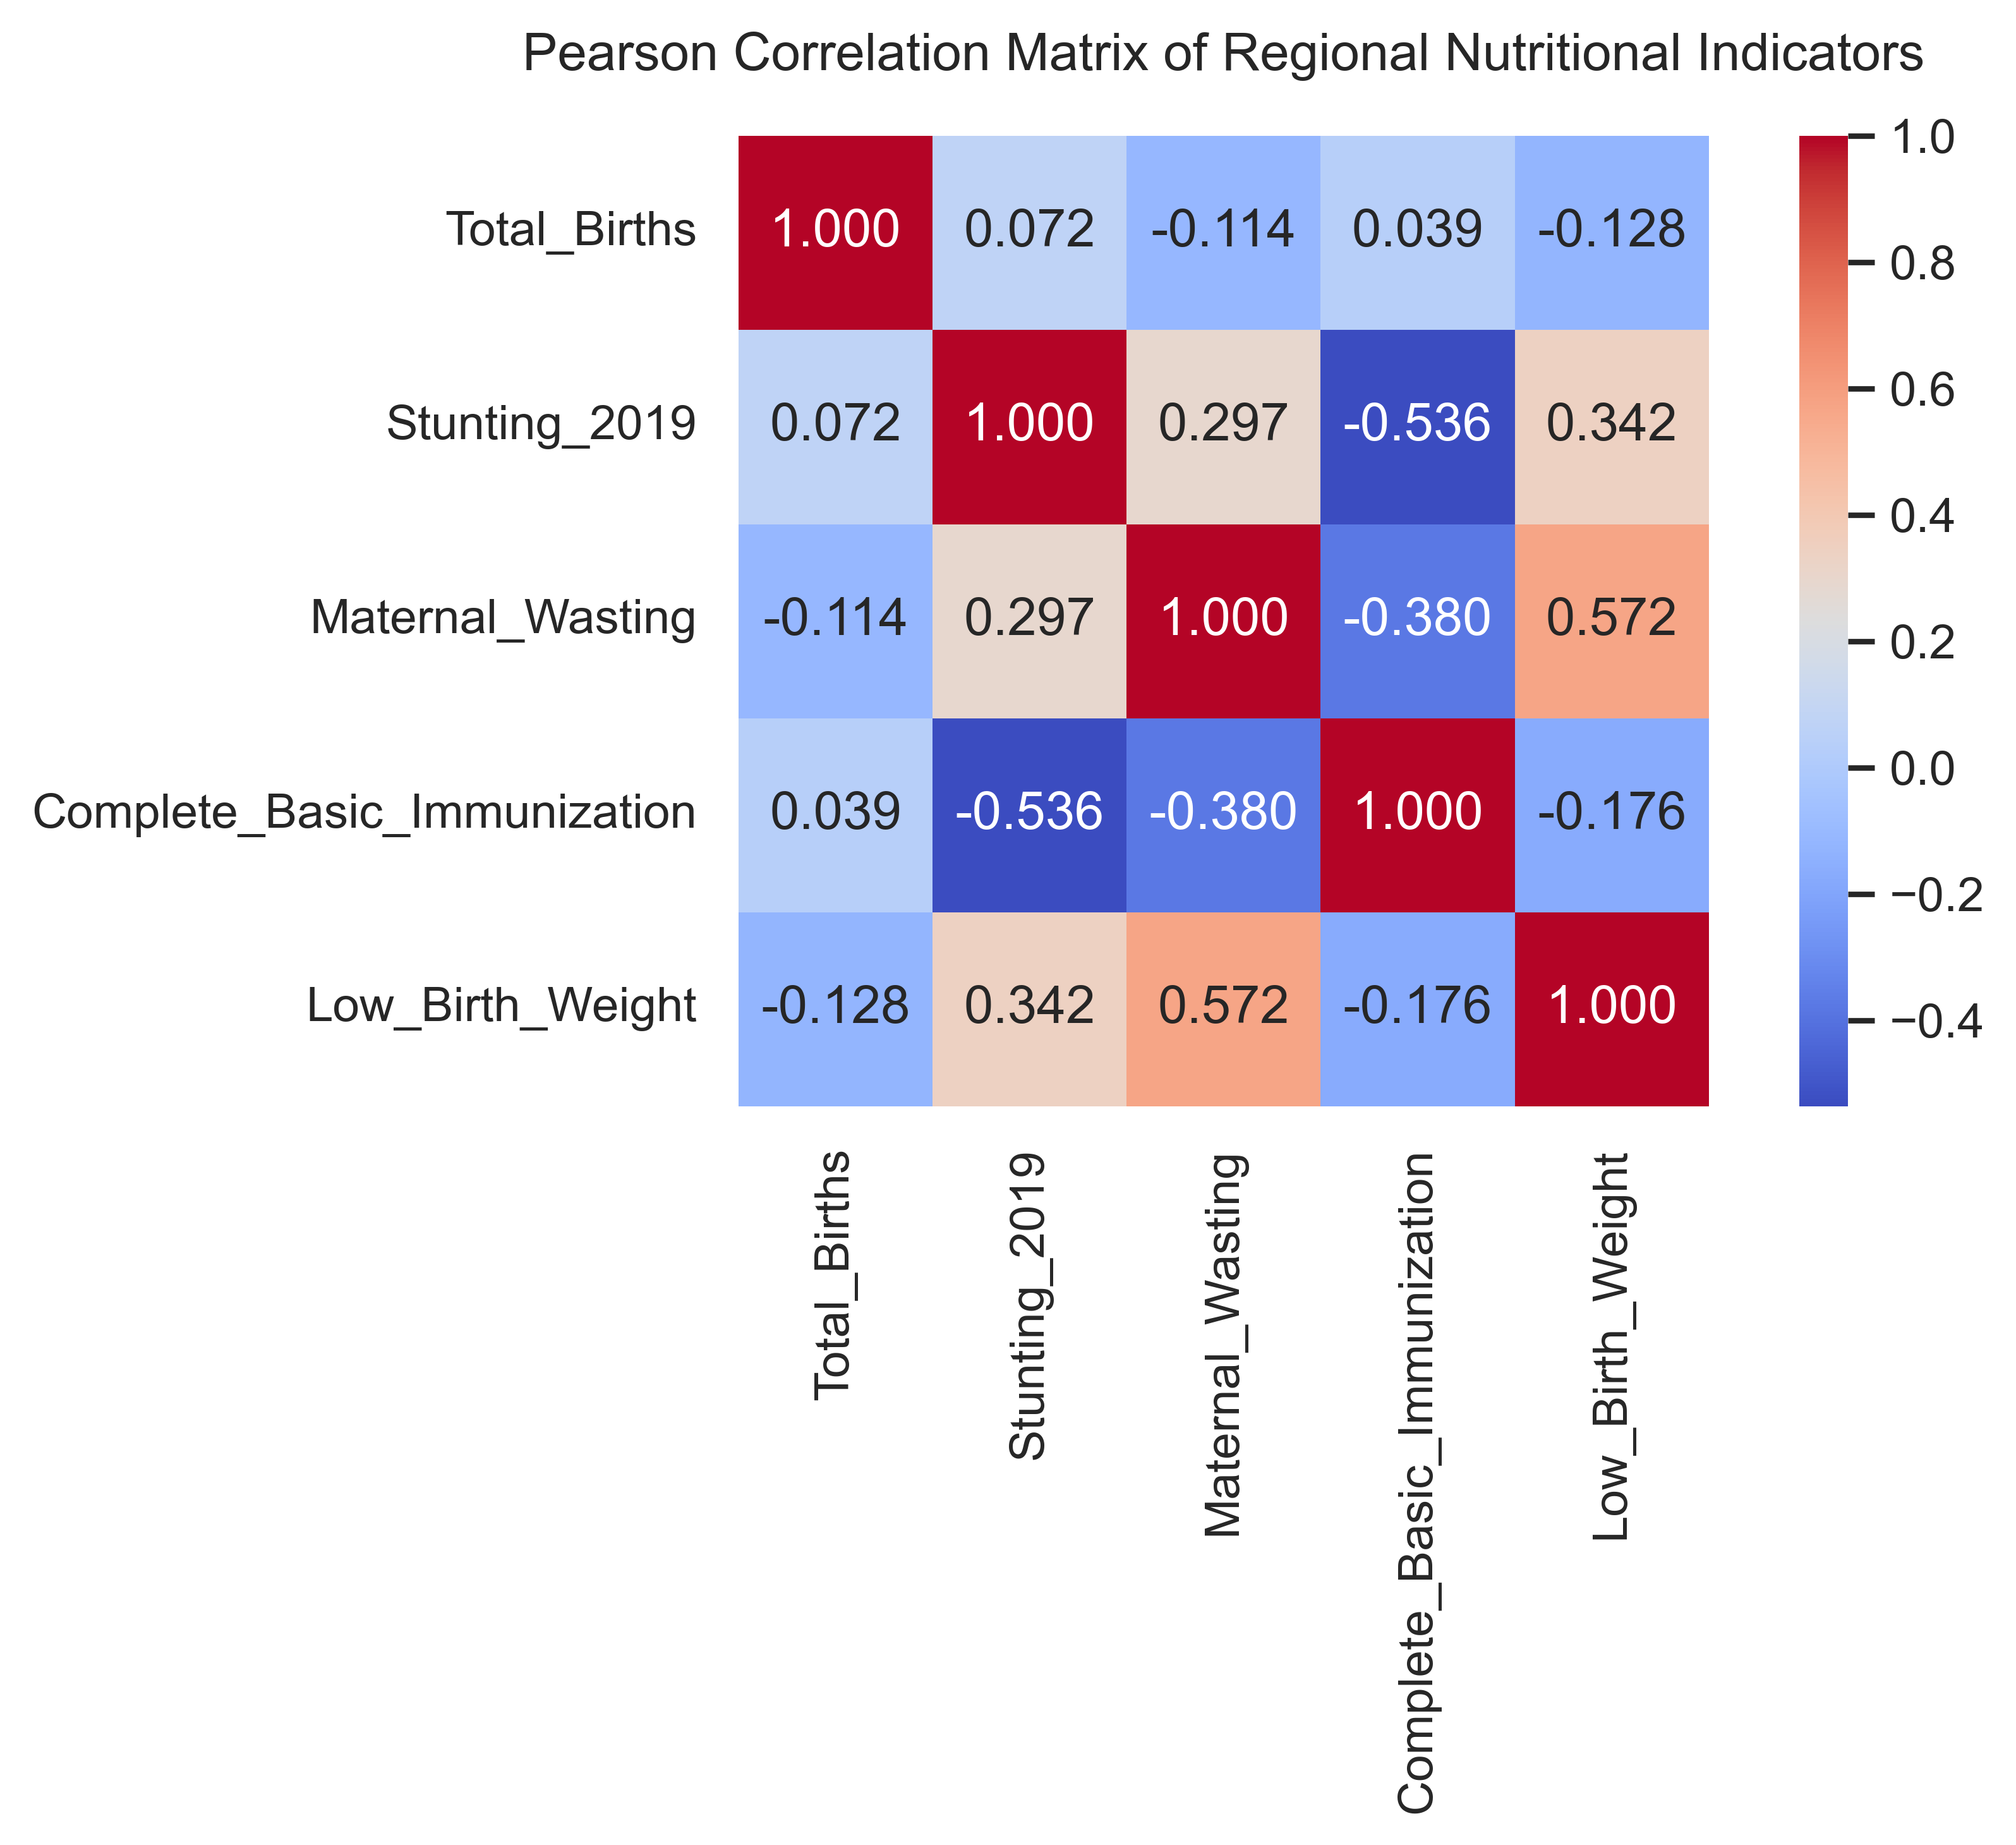

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_prov[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.3f', square=True)
plt.title('Pearson Correlation Matrix of Regional Nutritional Indicators', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('results/clustering/regional_nutrition_correlation.png', dpi=500, bbox_inches='tight')
plt.show()

## 6. Feature Standardization
Standardizes numerical features using `StandardScaler` to achieve zero mean and unit variance.

In [8]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_prov[numeric_cols])
df_scaled = pd.DataFrame(scaled_features, columns=numeric_cols, index=df_prov.index)
df_scaled.describe()

,Total_Births,Stunting_2019,Maternal_Wasting,Complete_Basic_Immunization,Low_Birth_Weight
count,3.400000e+01,3.400000e+01,3.400000e+01,3.400000e+01,3.400000e+01
mean,-1.567374e-16,2.644943e-16,-2.955152e-16,4.310278e-16,1.697988e-16
std,1.015038e+00,1.015038e+00,1.015038e+00,1.015038e+00,1.015038e+00
min,-7.128840e-01,-2.106069e+00,-1.932952e+00,-2.109270e+00,-2.058063e+00
25%,-5.785131e-01,-5.927438e-01,-6.100996e-01,-6.947409e-01,-5.831697e-01
50%,-3.706311e-01,3.629209e-02,-1.972546e-01,1.125503e-01,-1.611818e-01
75%,2.270597e-02,6.015594e-01,2.805482e-01,7.669896e-01,5.452448e-01
max,3.837443e+00,2.721125e+00,2.898069e+00,2.179759e+00,2.937407e+00


## 7. Determination of the Optimal Number of Clusters (500 DPI)
We evaluate the optimal number of clusters (K) using the Elbow Method and Silhouette Coefficient.

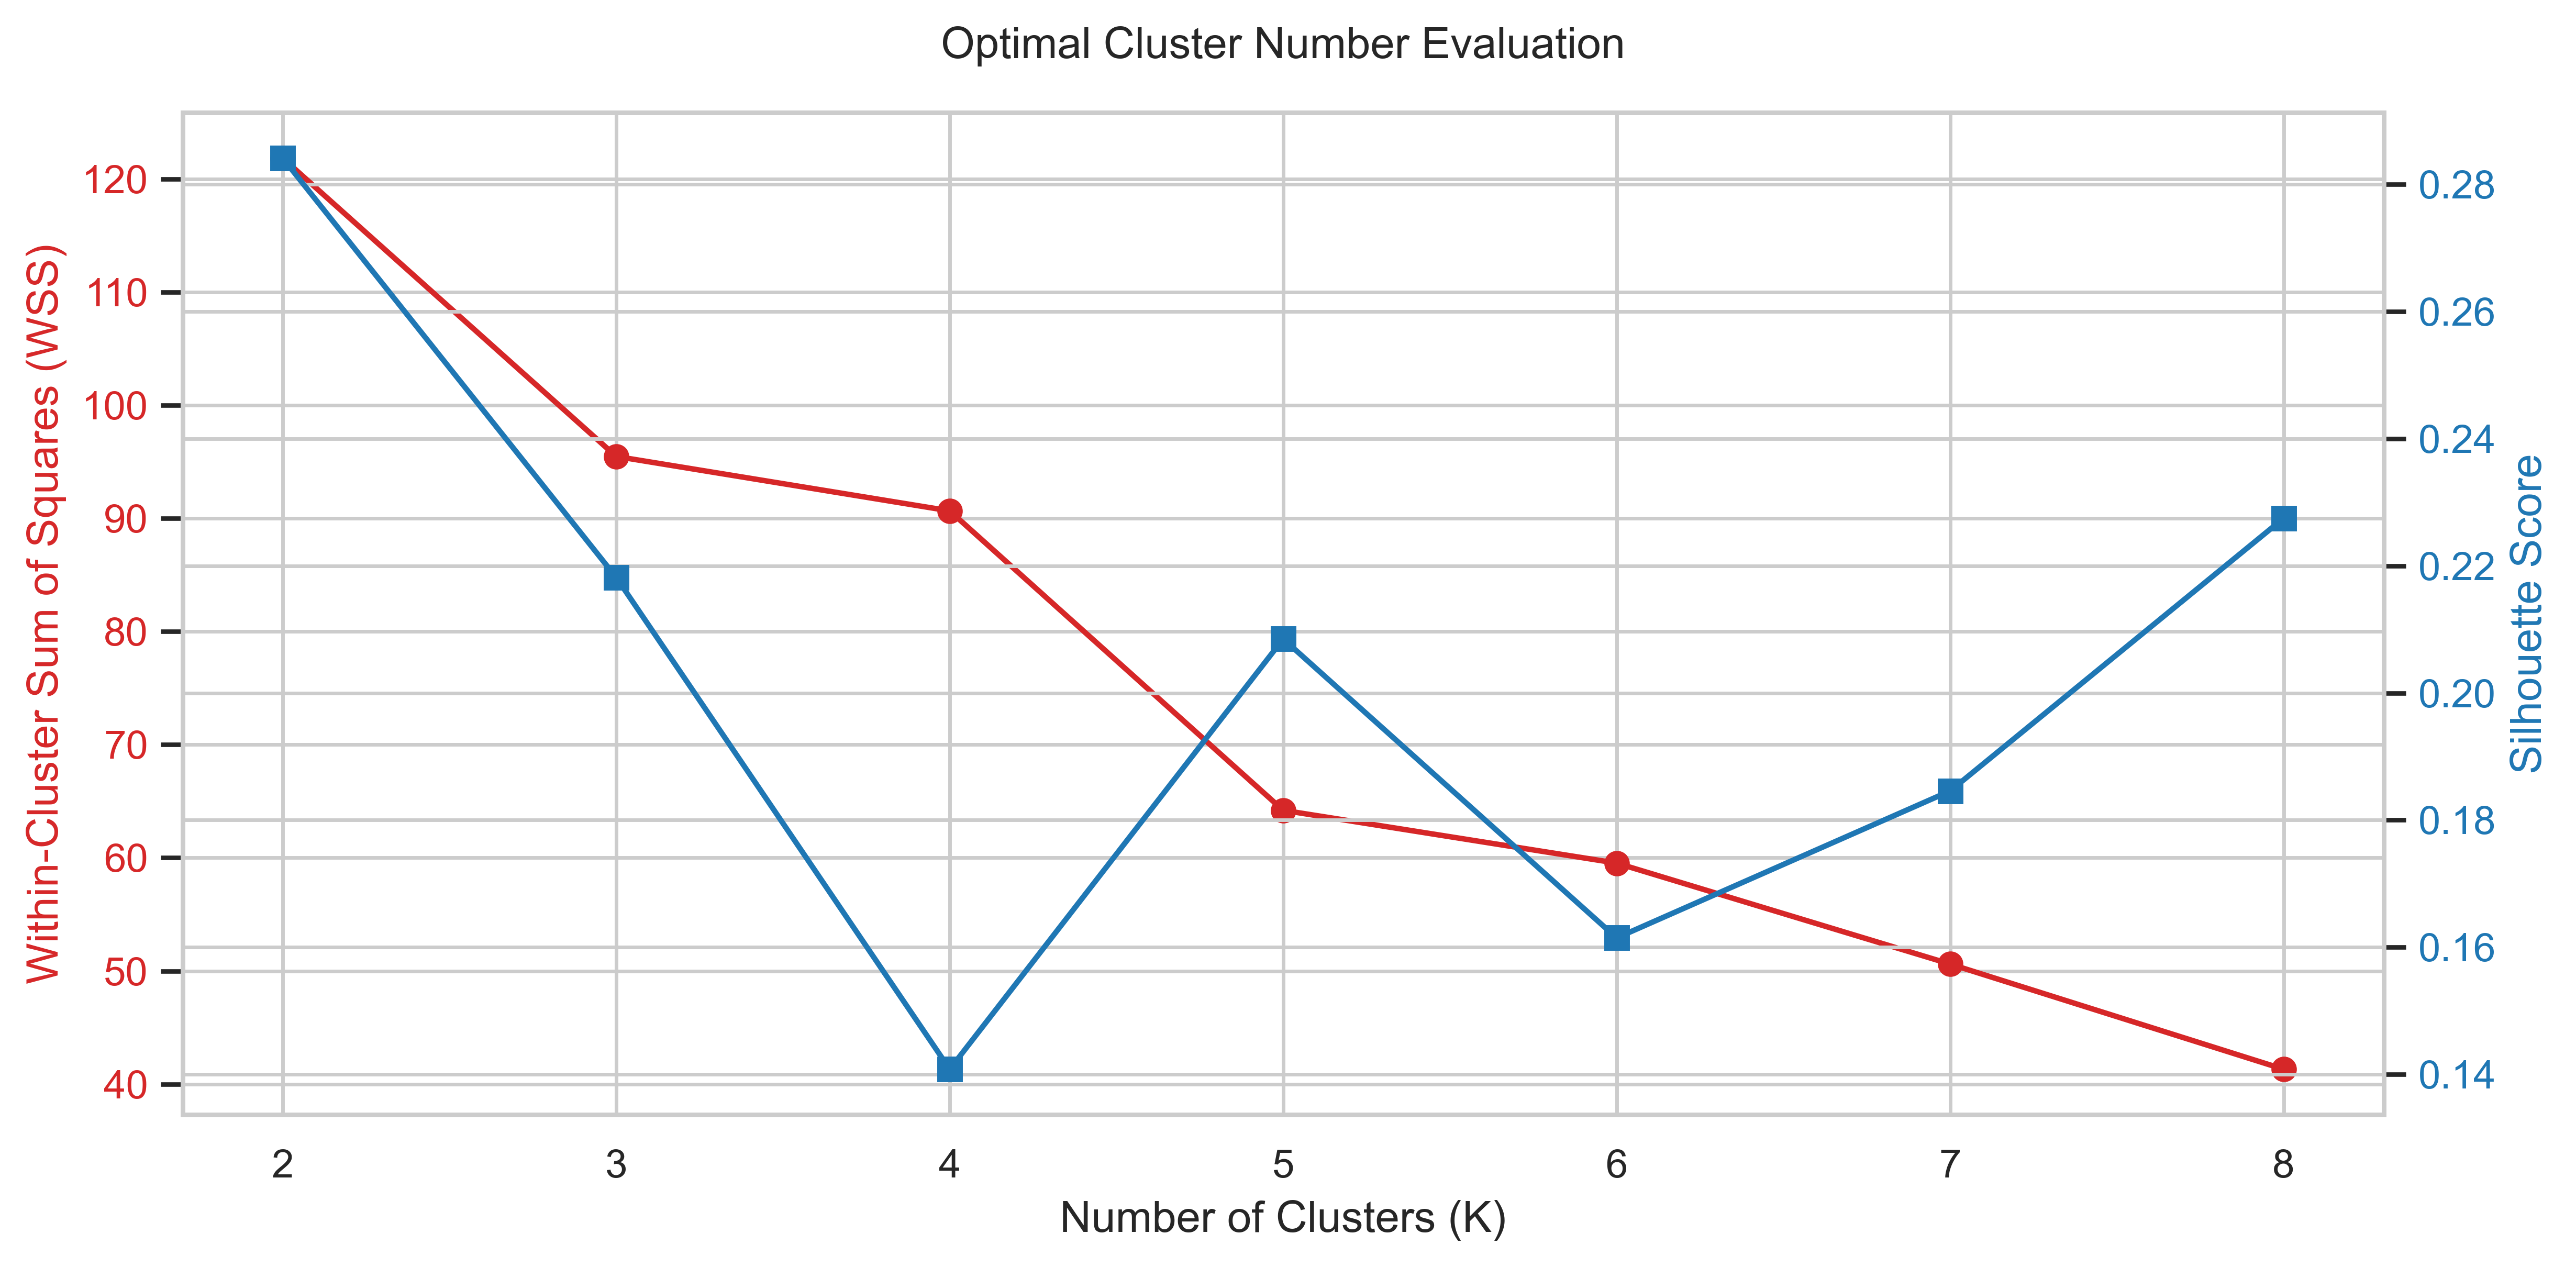

In [9]:
wss = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_scaled)
    wss.append(km.inertia_)
    sil_scores.append(silhouette_score(df_scaled, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:red'
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Within-Cluster Sum of Squares (WSS)', color=color)
ax1.plot(K_range, wss, 'o-', color=color, label='WSS')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, sil_scores, 's-', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimal Cluster Number Evaluation', fontsize=12, pad=15)
fig.tight_layout()
plt.savefig('results/clustering/optimal_k_evaluation.png', dpi=500, bbox_inches='tight')
plt.show()

## 8. Regional Clustering with K-Means, GMM, and Hierarchical Clustering
Applies K-Means, Gaussian Mixture Models, and Hierarchical Clustering with K=3.

In [10]:
# K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
df_prov['Cluster_KMeans'] = kmeans.fit_predict(df_scaled)

# Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)
df_prov['Cluster_GMM'] = gmm.fit_predict(df_scaled)

# Hierarchical Agglomerative
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
df_prov['Cluster_HC'] = hc.fit_predict(df_scaled)

print("All clustering models applied successfully!")

All clustering models applied successfully!


### 8.1 Hierarchical Clustering Dendrogram Visualization (500 DPI)
Displays the hierarchical grouping of provinces based on nutritional anthropometric profiles.

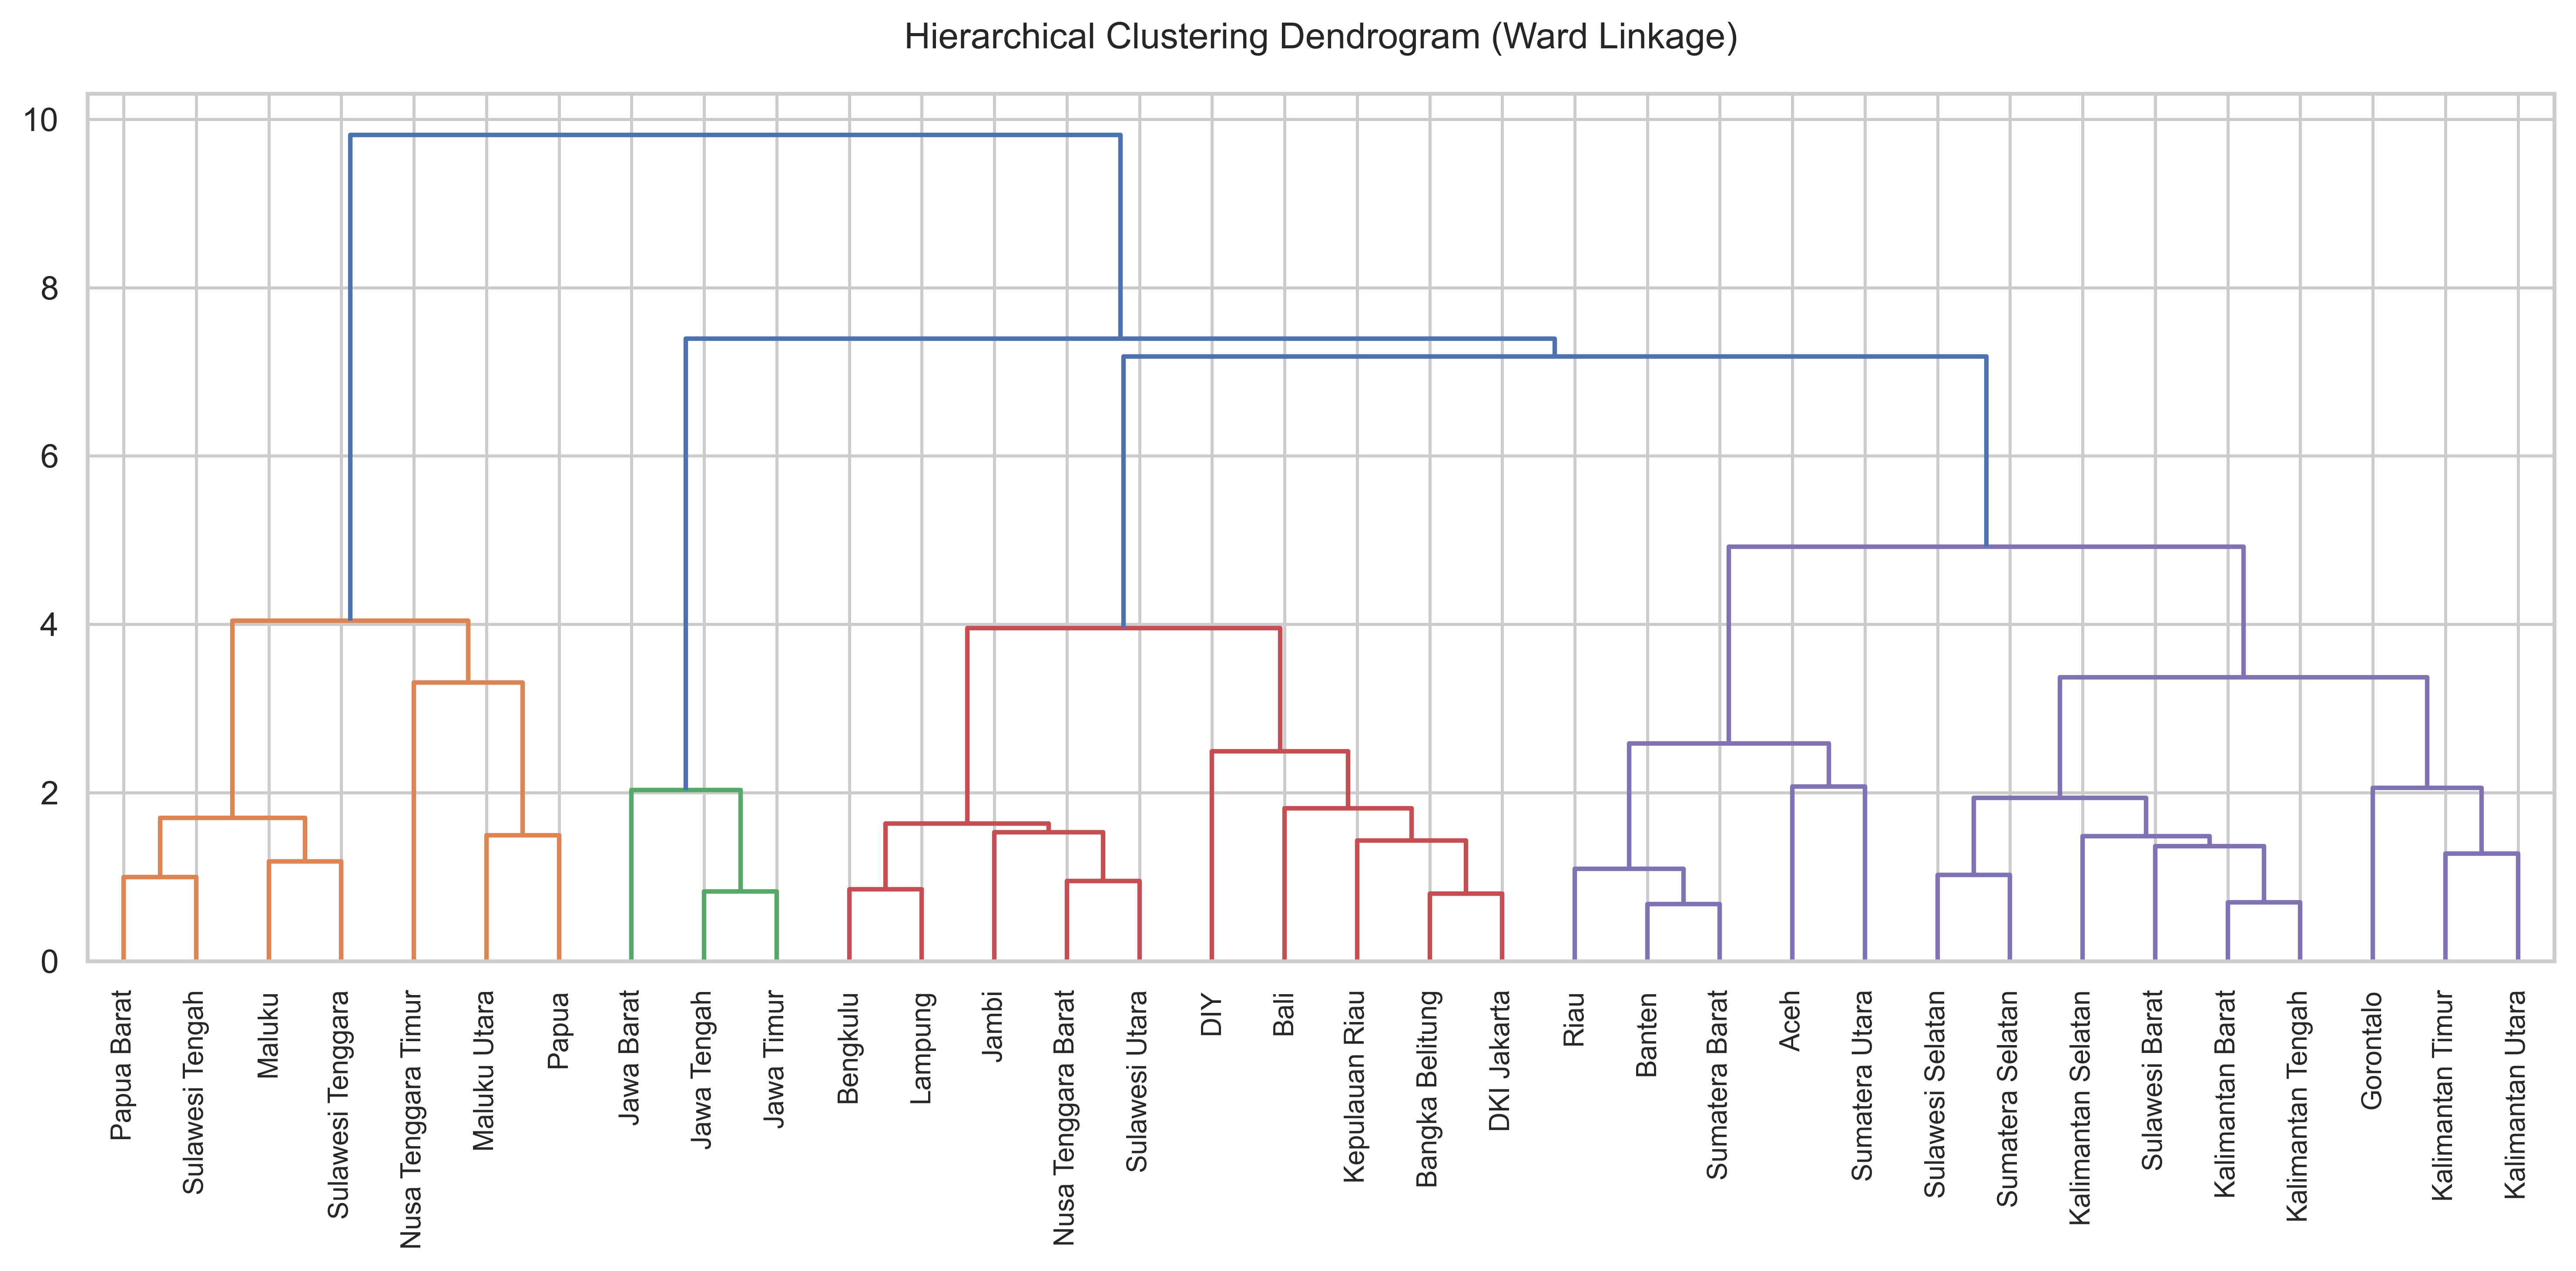

In [11]:
plt.figure(figsize=(12, 6))
linked = linkage(df_scaled, method='ward')
dendrogram(linked, labels=df_prov['Province'].values, leaf_rotation=90, leaf_font_size=9)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('results/clustering/regional_nutrition_dendrogram.png', dpi=500, bbox_inches='tight')
plt.show()

### 8.2 Cluster Consistency Analysis (Adjusted Rand Index)
Quantifies the consistency and similarity of partitions across the three clustering models.

In [12]:
ari_km_gmm = adjusted_rand_score(df_prov['Cluster_KMeans'], df_prov['Cluster_GMM'])
ari_km_hc = adjusted_rand_score(df_prov['Cluster_KMeans'], df_prov['Cluster_HC'])
ari_gmm_hc = adjusted_rand_score(df_prov['Cluster_GMM'], df_prov['Cluster_HC'])

print(f"Adjusted Rand Index (K-Means vs. GMM): {ari_km_gmm:.4f}")
print(f"Adjusted Rand Index (K-Means vs. Hierarchical): {ari_km_hc:.4f}")
print(f"Adjusted Rand Index (GMM vs. Hierarchical): {ari_gmm_hc:.4f}")

Adjusted Rand Index (K-Means vs. GMM): 0.9057
Adjusted Rand Index (K-Means vs. Hierarchical): 0.3818
Adjusted Rand Index (GMM vs. Hierarchical): 0.3169


### 8.3 Cluster Quality Metrics Evaluation
Computes Silhouette, Davies-Bouldin, and Calinski-Harabasz indices for the models.

In [13]:
metrics = {}
for name, col in [('K-Means', 'Cluster_KMeans'), ('GMM', 'Cluster_GMM'), ('Hierarchical', 'Cluster_HC')]:
    sil = silhouette_score(df_scaled, df_prov[col])
    db = davies_bouldin_score(df_scaled, df_prov[col])
    ch = calinski_harabasz_score(df_scaled, df_prov[col])
    metrics[name] = {'Silhouette Score': sil, 'Davies-Bouldin Index': db, 'Calinski-Harabasz Index': ch}

df_metrics = pd.DataFrame(metrics).T
df_metrics

,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
K-Means,0.218165,1.272105,12.096479
GMM,0.199484,1.323591,11.343325
Hierarchical,0.319915,0.987706,12.378914


## 9. Profiling of Selected Provincial Clusters
Analyzes the mean characteristics of nutritional indicators for each cluster.

In [14]:
profile = df_prov.groupby('Cluster_KMeans')[numeric_cols].mean()
print("Mean Nutritional Indicator Profiles per Cluster:")
profile

Mean Nutritional Indicator Profiles per Cluster:


,Total_Births,Stunting_2019,Maternal_Wasting,Complete_Basic_Immunization,Low_Birth_Weight
Cluster_KMeans,,,,,
0,248951.275579,30.722239,0.156987,0.543519,0.062335
1,89894.044714,33.749914,0.329735,0.412994,0.083321
2,68014.153750,20.681462,0.190328,0.720483,0.059486


### 9.1 Cluster Scatterplot Visualization: Stunting vs. Maternal Wasting (500 DPI)
Visualizes the cluster separation based on the two most critical features.

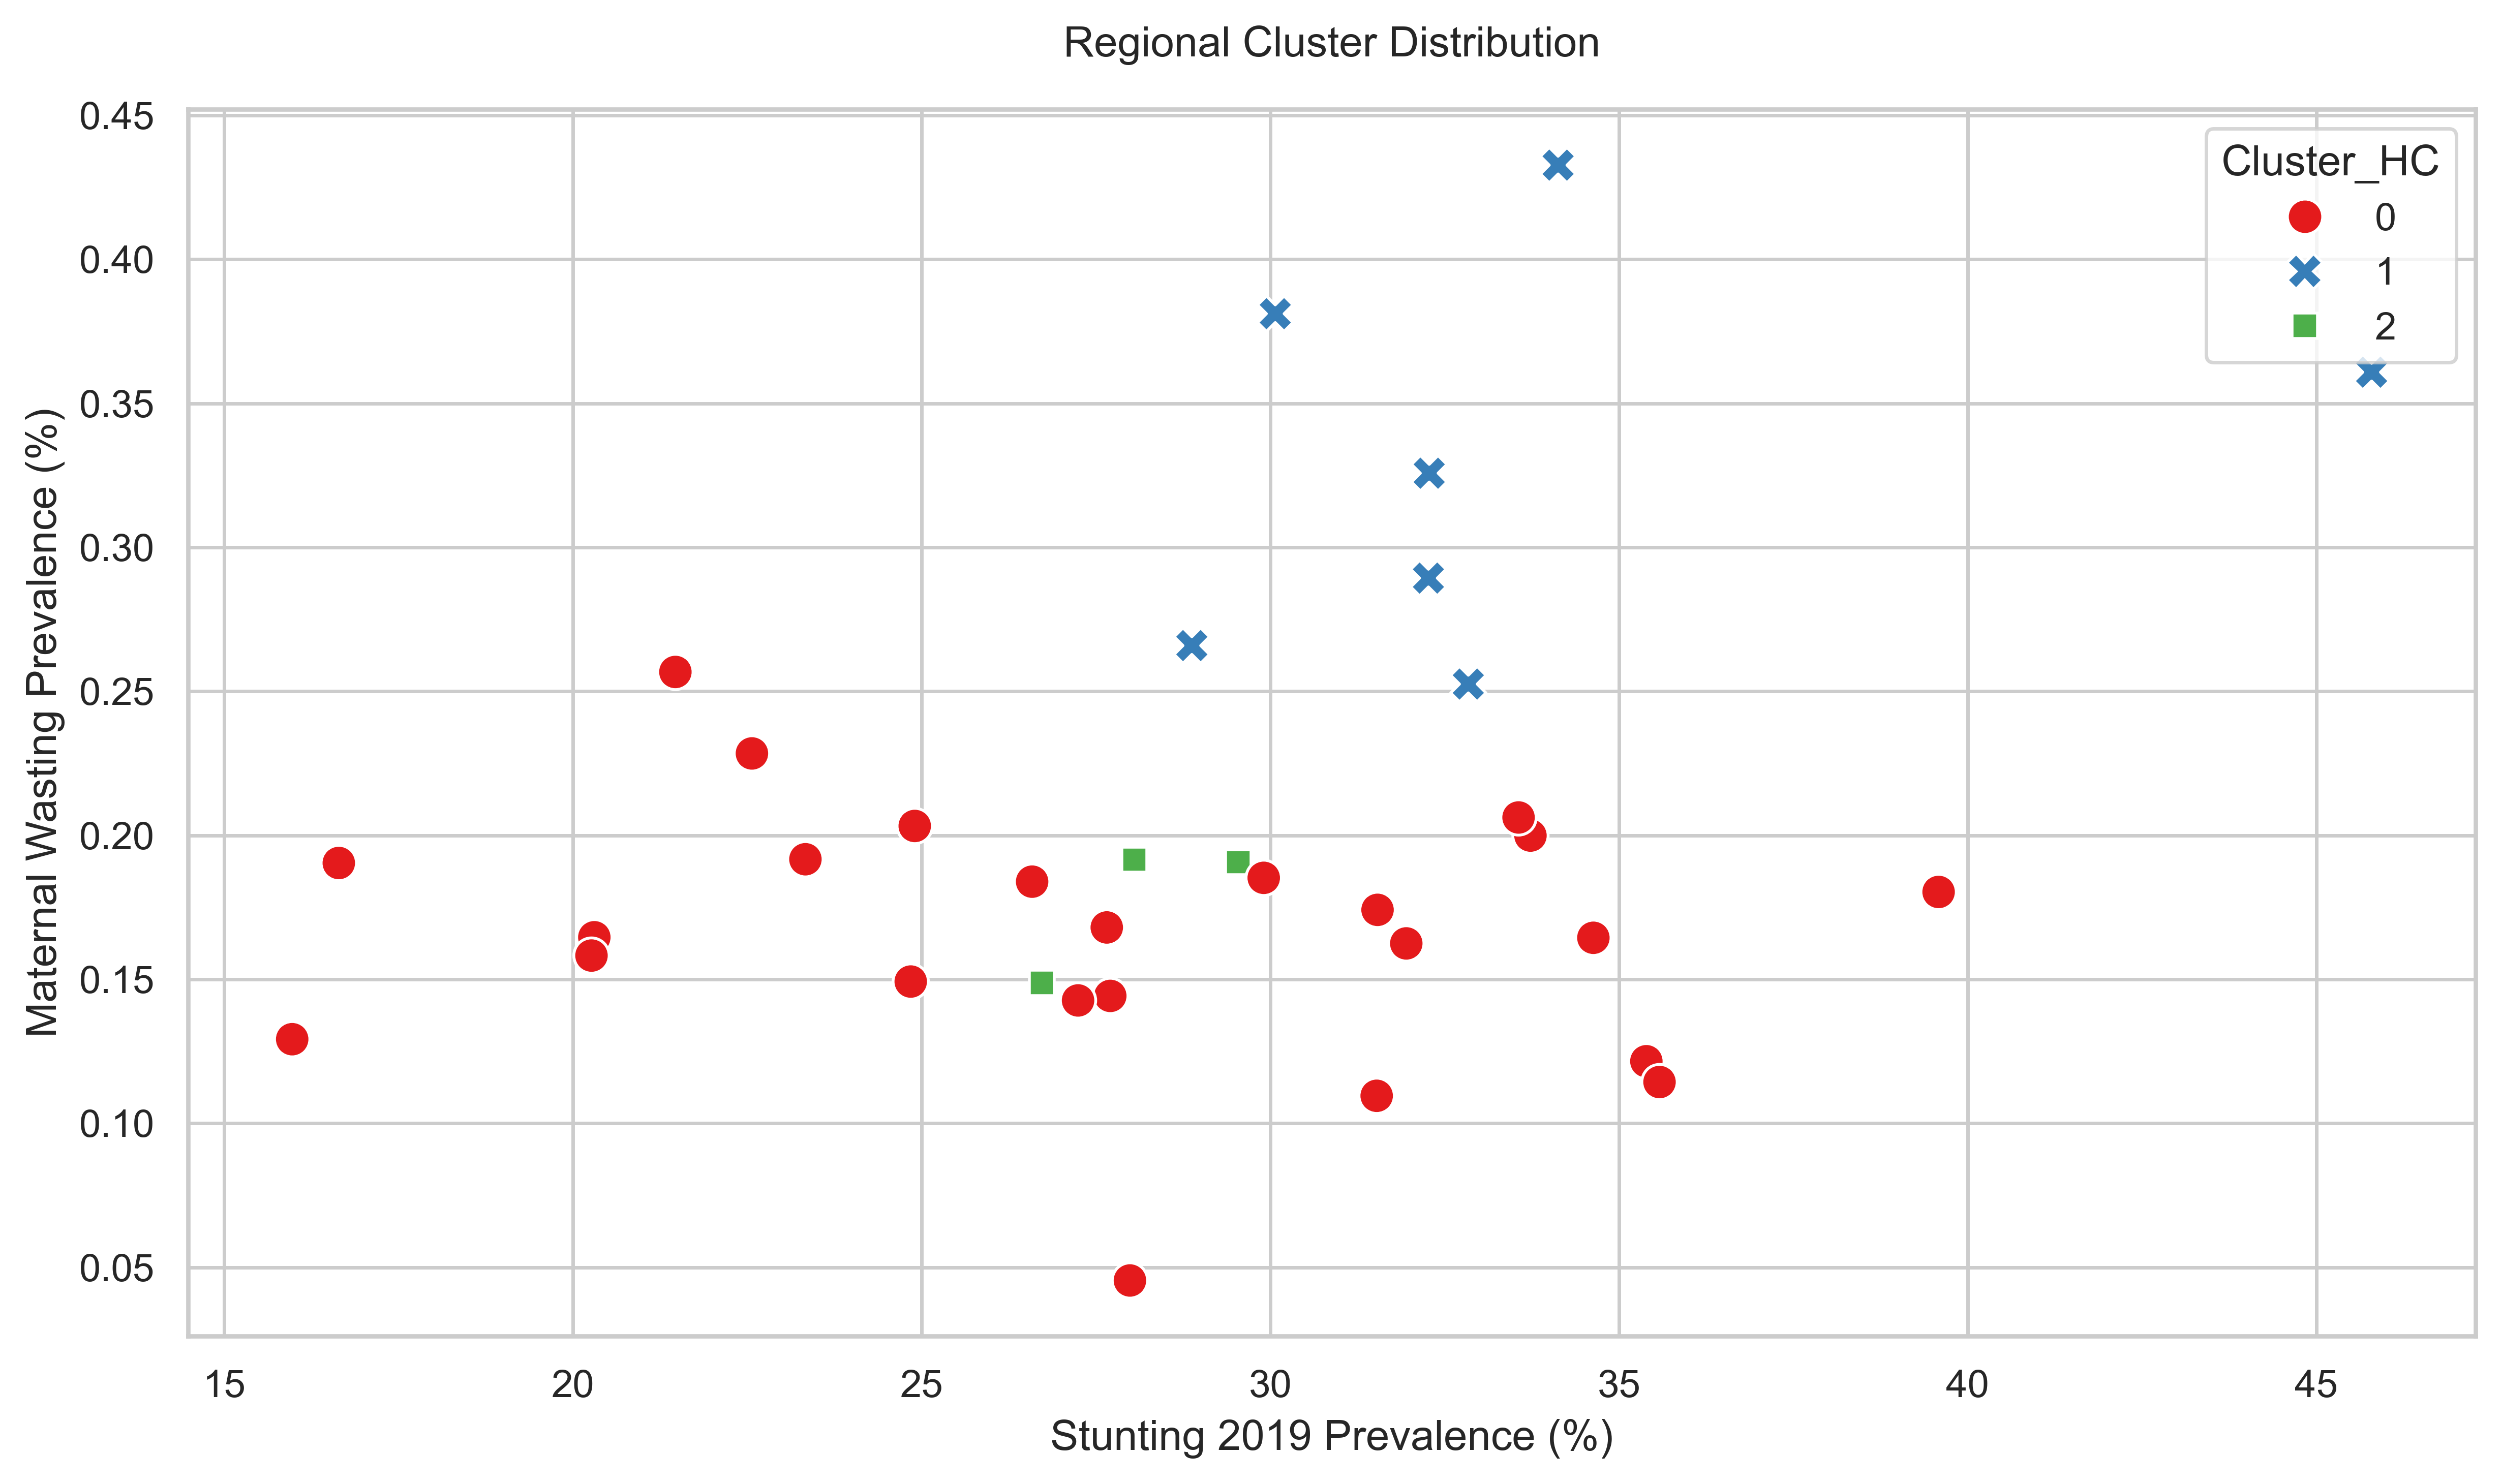

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_prov,
    x='Stunting_2019',
    y='Maternal_Wasting',
    hue='Cluster_HC',
    palette='Set1',
    s=100,
    style='Cluster_HC'
)
plt.title('Regional Cluster Distribution', fontsize=12, pad=15)
plt.xlabel('Stunting 2019 Prevalence (%)')
plt.ylabel('Maternal Wasting Prevalence (%)')
plt.tight_layout()
plt.savefig('results/clustering/regional_cluster_scatterplot.png', dpi=500, bbox_inches='tight')
plt.show()

## 10. Interactive Spatial Mapping of Indonesian Provinces (Folium)
Generates an interactive Choropleth map of Indonesian provinces color-coded by nutrition cluster.

In [16]:
# Load spatial administrative boundaries of Indonesian provinces
with open('dataset/indonesia-province-simple.json', 'r', encoding='utf-8') as f:
    geojson_data = json.load(f)

# Standardize province names to match GeoJSON names
geojson_provs = [feature['properties']['Propinsi'] for feature in geojson_data['features']]

prov_map = {
    'DKI Jakarta': 'Jakarta Raya',
    'Bangka Belitung': 'Kepulauan Bangka Belitung',
    'DI Yogyakarta': 'Yogyakarta',
    'Nanggroe Aceh Darussalam': 'Aceh'
}
df_prov['Province_Map'] = df_prov['Province'].replace(prov_map)

# Create base map centered at the coordinates of Central Indonesia
m = folium.Map(location=[-2.5, 118], zoom_start=5)

# Membuat layer Choropleth
folium.Choropleth(
    geo_data=geojson_data,
    name='choropleth',
    data=df_prov,
    columns=['Province_Map', 'Cluster_KMeans'],
    key_on='feature.properties.Propinsi',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Nutrition Cluster (0=Good, 1=Moderate, 2=Critical)'
).add_to(m)

# Menyimpan peta
m.save('results/clustering/indonesia_stunting_map.html')
print("Interactive geographic Choropleth map saved to results/clustering/indonesia_stunting_map.html")

Interactive geographic Choropleth map saved to results/clustering/indonesia_stunting_map.html


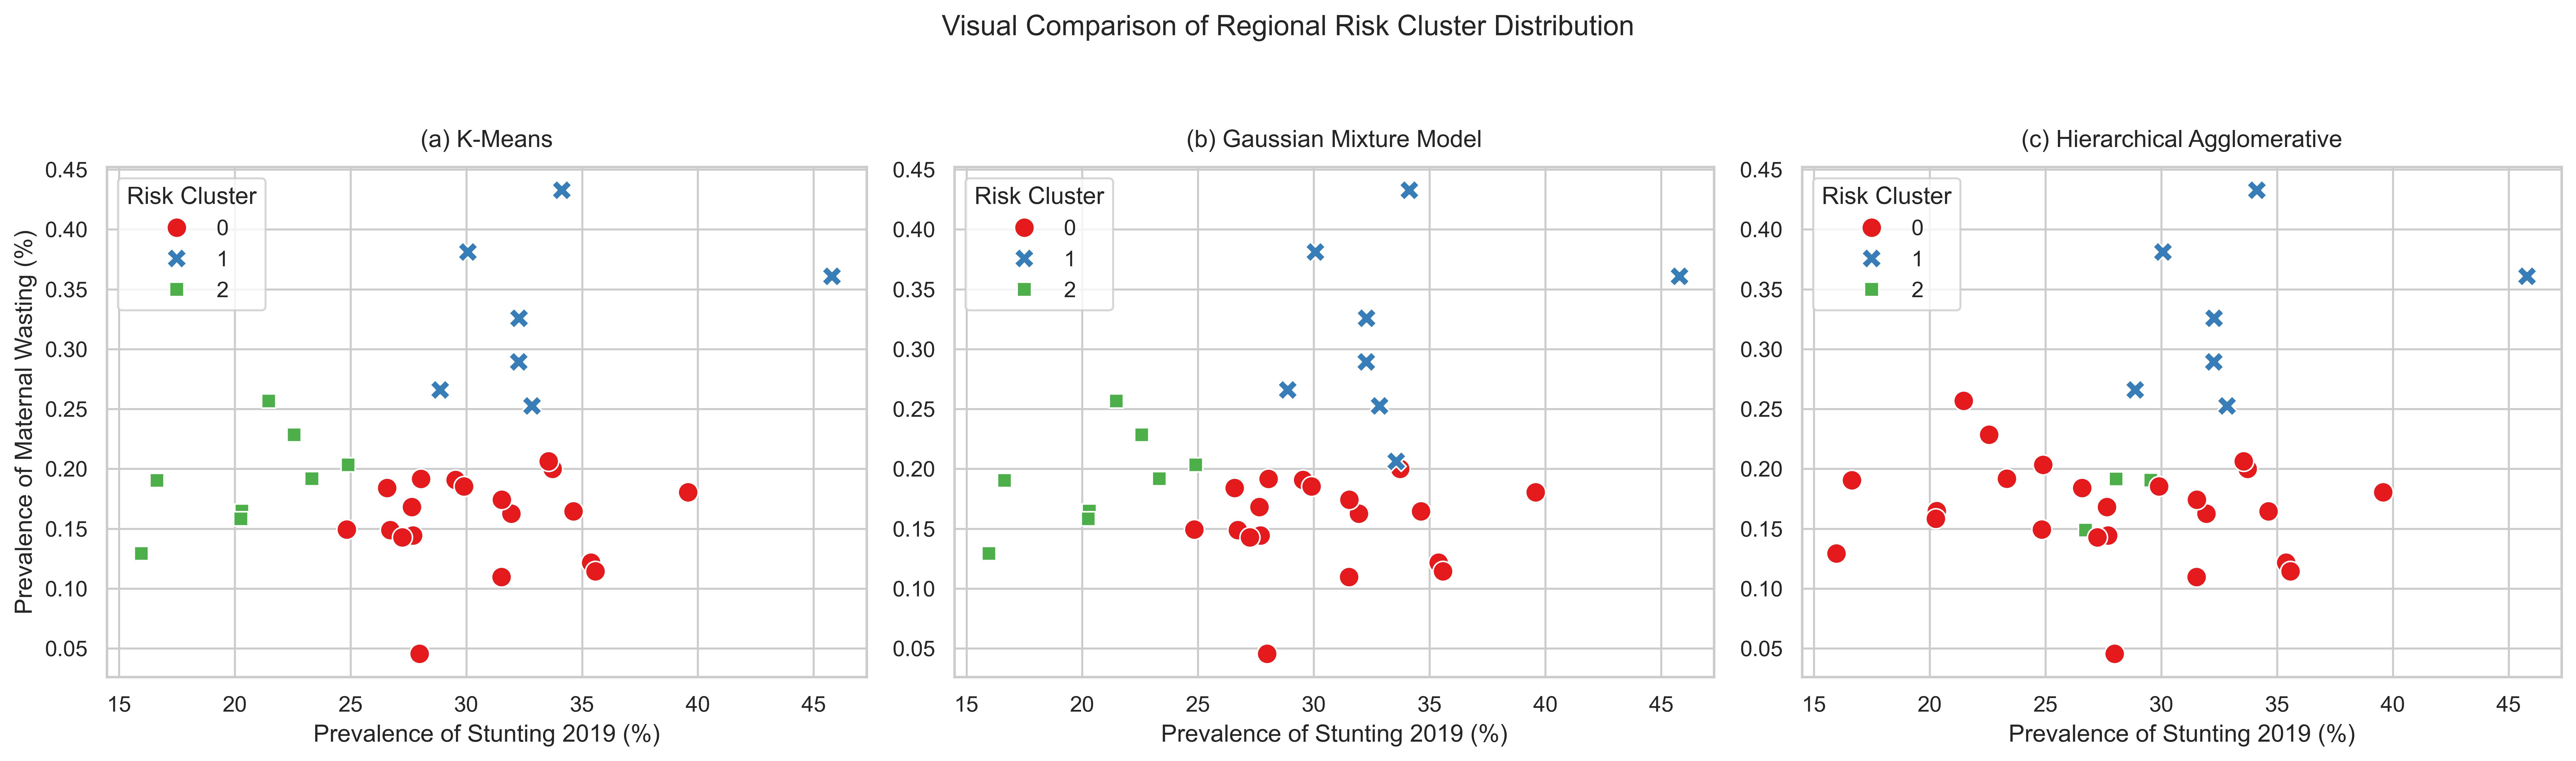

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- (a) Plot for K-Means ---
sns.scatterplot(
    data=df_prov, x='Stunting_2019', y='Maternal_Wasting',
    hue='Cluster_KMeans', palette='Set1', s=100, style='Cluster_KMeans', ax=axes[0]
)
axes[0].set_title('(a) K-Means', fontsize=12, pad=10)
axes[0].set_xlabel('Prevalence of Stunting 2019 (%)')
axes[0].set_ylabel('Prevalence of Maternal Wasting (%)')
axes[0].legend(title='Risk Cluster')

# --- (b) Plot for GMM ---
sns.scatterplot(
    data=df_prov, x='Stunting_2019', y='Maternal_Wasting',
    hue='Cluster_GMM', palette='Set1', s=100, style='Cluster_GMM', ax=axes[1]
)
axes[1].set_title('(b) Gaussian Mixture Model', fontsize=12, pad=10)
axes[1].set_xlabel('Prevalence of Stunting 2019 (%)')
axes[1].set_ylabel('')  # Dikosongkan agar rapi
axes[1].legend(title='Risk Cluster')

# --- (c) Plot for Hierarchical ---
sns.scatterplot(
    data=df_prov, x='Stunting_2019', y='Maternal_Wasting',
    hue='Cluster_HC', palette='Set1', s=100, style='Cluster_HC', ax=axes[2]
)
axes[2].set_title('(c) Hierarchical Agglomerative', fontsize=12, pad=10)
axes[2].set_xlabel('Prevalence of Stunting 2019 (%)')
axes[2].set_ylabel('')  # Dikosongkan agar rapi
axes[2].legend(title='Risk Cluster')

plt.suptitle('Visual Comparison of Regional Risk Cluster Distribution', fontsize=14, y=1.05)

# Save the figure with IEEE standard (DPI 500 and without title)
plt.tight_layout()
plt.savefig('results/clustering/scatter_klaster_komparasi.png', dpi=500, bbox_inches='tight')
plt.show()
